1.LOAD DATASET

In [14]:
import pandas as pd

PLATFORM = "Reddit"

train_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/reddit_train.csv"
)

test_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/reddit_test.csv"
)

print(train_df.shape)
print(test_df.shape)

(30068, 56)
(7517, 56)


In [2]:
print("\n" + "="*30)
print("TRAIN CLASS DISTRIBUTION")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nProportion %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("TEST CLASS DISTRIBUTION")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nProportion %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


TRAIN CLASS DISTRIBUTION
popularity
0    23931
1     6137
Name: count, dtype: int64

Proportion %:
popularity
0    79.589597
1    20.410403
Name: proportion, dtype: float64

TEST CLASS DISTRIBUTION
popularity
0    5983
1    1534
Name: count, dtype: int64

Proportion %:
popularity
0    79.592923
1    20.407077
Name: proportion, dtype: float64


In [16]:
negative_count = train_df["popularity"].value_counts()[0]
positive_count = train_df["popularity"].value_counts()[1]

ratio = negative_count / positive_count
print(f"scale_pos_weight = {ratio:.2f}")

scale_pos_weight = 3.90


In [15]:
X_train = train_df.drop(
    columns=[
        "post_id",
        "user_id",
        "popularity"
    ]
)
y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=[
        "post_id",
        "user_id",
        "popularity"
    ]
)
y_test = test_df["popularity"]

In [ ]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     
    n_estimators=500,           
    learning_rate=0.02,         
    max_depth=6,                
    min_child_weight=1,         
    gamma=0.1,                  
    subsample=0.8,              
    colsample_bytree=0.5,       
    random_state=42,            
    n_jobs=-1                   
)

In [34]:
print("TRAINING XGBOOST...")
model.fit(
    X_train,
    y_train
)

TRAINING XGBOOST...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [35]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


In [36]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [37]:
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.93      0.74      0.82      5983
           1       0.43      0.78      0.55      1534

    accuracy                           0.74      7517
   macro avg       0.68      0.76      0.69      7517
weighted avg       0.83      0.74      0.77      7517

ROC-AUC  : 0.8432


In [38]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("CONFUSION MATRIX")
print(cm)

CONFUSION MATRIX
[[4405 1578]
 [ 341 1193]]


In [11]:
importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 15 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(15)
)


TOP 15 IMPORTANT FEATURES
                feature  importance
3             followers    0.296565
5              verified    0.027441
40      language_Korean    0.015626
27         topic_Gaming    0.015509
22      topic_Education    0.015344
26           topic_Food    0.015263
6        content_length    0.015109
4      account_age_days    0.014975
23  topic_Entertainment    0.014967
10       toxicity_score    0.014714
41  language_Portuguese    0.014663
9    sentiment_negative    0.014517
28         topic_Health    0.014510
18  sentiment_intensity    0.014483
39    language_Japanese    0.014409


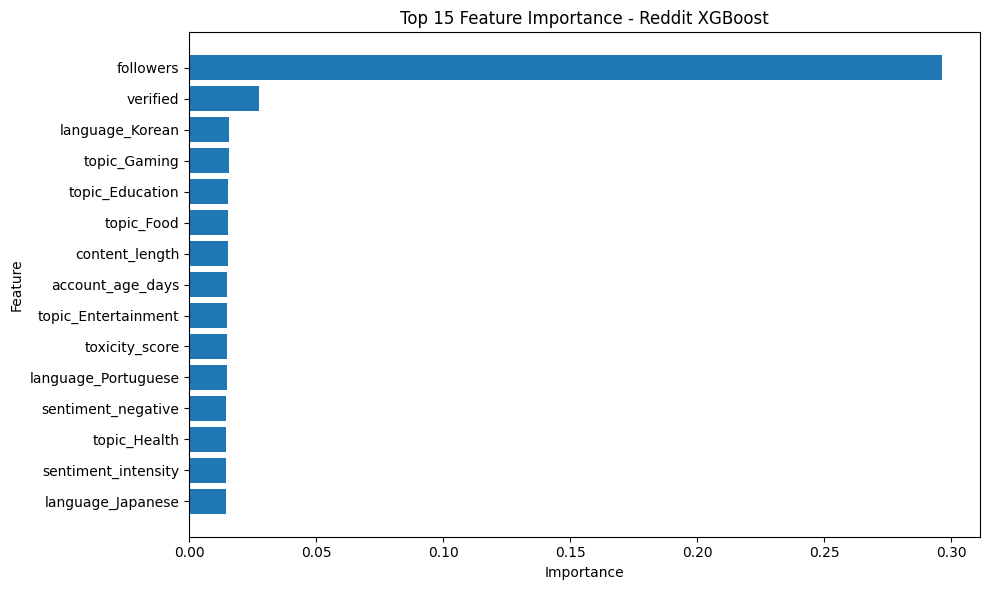

In [12]:
import matplotlib.pyplot as plt
top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Feature Importance - Reddit XGBoost"
)

plt.tight_layout()

plt.show()